In [1]:
import matplotlib.pyplot as plt
import numpy as np

from spectrumlab.peaks.analyte_peaks.intensity.transformers import (
    RegressionIntensityTransformer,
    estimate_bounds,
    process_frame,
)
from spectrumlab.types import Frame

from plugin.configs import PLUGIN_CONFIG
from plugin.managers.data_source_manager import DataSourceManager
from plugin.managers.data_source_manager.data_sources import XMLDataSource

In [2]:
data_source_manager = DataSourceManager(
    data_source=XMLDataSource(
        xml='<input>{filepath}</input>'.format(filepath=PLUGIN_CONFIG.filepath),
    ),
)
atom_data = data_source_manager.load()

In [3]:
def build_result(
    datum,
    transformer: RegressionIntensityTransformer,
):

    frame = datum.frame.copy()
    frame = frame.dropna(subset=['concentration'])
    frame = frame.groupby(level=0, sort=False).mean()
    frame['intensity_hat'] = frame['value'].map(transformer.predict).map(np.nansum)

    result = frame[['concentration', 'intensity', 'intensity_hat']]
    return result


def estimate_relative_deviation(
    result: Frame,
) -> float:

    intercept = np.mean(np.log10(result['intensity_hat']) - np.log10(result['concentration']))
    approx = np.log10(result['concentration']) + intercept

    relative_deviation = np.abs((np.log10(result['intensity_hat']) - approx) / approx)
    return relative_deviation


In [6]:
for column_id, datum in atom_data.data.items():

    frame = datum.frame.copy()
    data = process_frame(frame)
    bounds = estimate_bounds(data, threshold=.05)

    transformer = RegressionIntensityTransformer.create(
        intensity=frame['intensity'],
        concentration=frame['concentration'],
        bounds=bounds,
    )
    result = build_result(
        datum=datum,
        transformer=transformer,
    )

    relative_deviation = estimate_relative_deviation(result)
    result['relative_deviation'] = relative_deviation


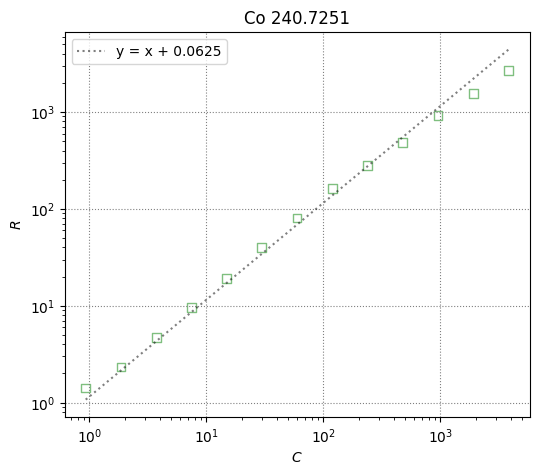

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

x = result['concentration']
y = result['intensity_hat']
plt.scatter(
    x, y,
    s=40,
    marker='s',
    facecolors='none',
    edgecolors='green',
    alpha=.5,
)

b = np.mean(np.log10(result['intensity_hat']) - np.log10(result['concentration']))
x = np.linspace(np.log10(x).min(), np.log10(x).max(), 200)
y = x + b
plt.plot(
    10**(x), 10**(y),
    color='black',
    linestyle=':',
    alpha=.5,
    label='y = x + {b:.4f}'.format(b=b),
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$C$')
plt.ylabel(r'$R$')
plt.title(datum.nickname)
plt.grid(color='grey', linestyle=':')
plt.legend()

plt.show()

In [8]:
result

,concentration,intensity,intensity_hat,relative_deviation
probe_name,,,,
СО 11 ЭЛ 13,0.93,0.019548,1.413617,3.845533
СО 11 ЭЛ 12,1.86,0.035439,2.334857,0.109035
СО 11 ЭЛ 11,3.72,0.065574,4.717517,0.064176
СО 11 ЭЛ 10,7.45,0.115395,9.524802,0.047243
СО 11 ЭЛ 9,14.90,0.202714,19.268162,0.039743
СО 11 ЭЛ 8,29.80,0.331832,39.966037,0.042253
СО 11 ЭЛ 6,59.60,0.481519,80.575589,0.037227
СО 11 ЭЛ 5,119.20,0.666889,162.767336,0.034014
СО 11 ЭЛ 4,238.41,1.001048,282.486499,0.004562
